In [2]:
import trimesh as tm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import vedo as v
from io import BytesIO
# %matplotlib inline

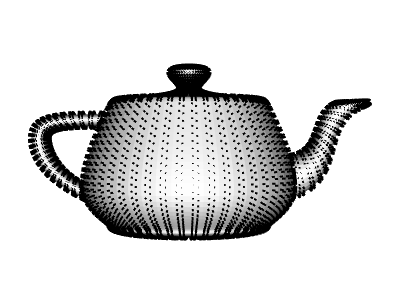

In [3]:
obj = tm.load_mesh("simple.stl")

obj.apply_transform(tm.transformations.rotation_matrix(np.radians(-90),[1, 0, 0]))

# obj.visual.to_color()
obj.visual.face_colors = [255, 255, 255, 255]

line_s = []
line_e = []
normal_len = 0.2
vertex_norm = {}
face_normals = np.zeros((len(obj.faces), 3), np.float64)
for f_i, face in enumerate(obj.faces):
    vert_0, vert_1, vert_2 = map(lambda x: obj.vertices[x], face)
    vect_0 = vert_1 - vert_0
    vect_1 = vert_2 - vert_0
    normal = np.cross(vect_0, vect_1)
    normal = normal / np.linalg.norm(normal)
    face_normals[f_i] = normal
    
    for i in face:
        if i in vertex_norm.keys():
            vertex_norm[i].append(normal)
        else:
            vertex_norm[i] = [normal]
    
    face_center = (vert_0 + vert_1 + vert_2) / 3
    line_s.append(face_center)
    line_e.append(face_center + normal * normal_len)
normals = v.Lines(line_s, line_e, lw=2, c="black")

v.show([obj, normals], size=(400,300), zoom=1.5)

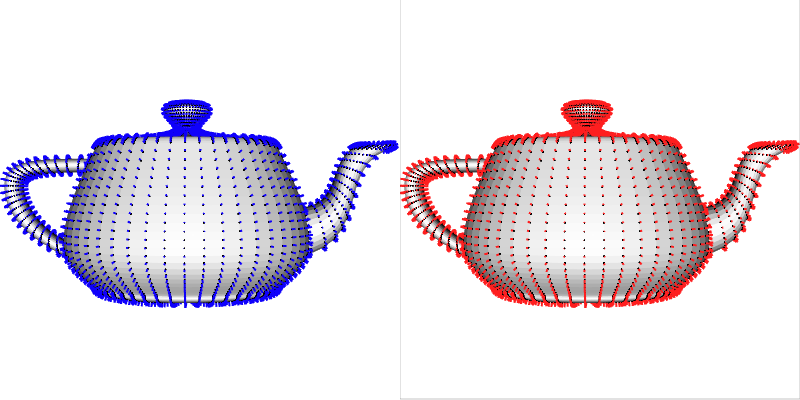

In [4]:
points = v.Points(obj.vertices, c = "black", r=2)
line_s = []
line_e = []
for index, normal in vertex_norm.items():
    vert = obj.vertices[index]
    avg_norm = sum(normal) / len(normal)
    line_s.append(vert)
    line_e.append(vert + avg_norm * normal_len)
vertex_normals_calc = v.Lines(line_s, line_e, lw=2, c="blue")
vertex_normals_base = v.Lines(
    obj.vertices,
    np.array(tuple(map(lambda x,y: x + y * normal_len, obj.vertices, obj.vertex_normals)), dtype="float"),
    lw=2, c="red")

vplt = v.Plotter(shape=[1, 2], size=(800,400))
vplt.at(0)
vplt += [obj, points, vertex_normals_calc]
vplt.at(1)
vplt += [obj, points, vertex_normals_base]
vplt.show()

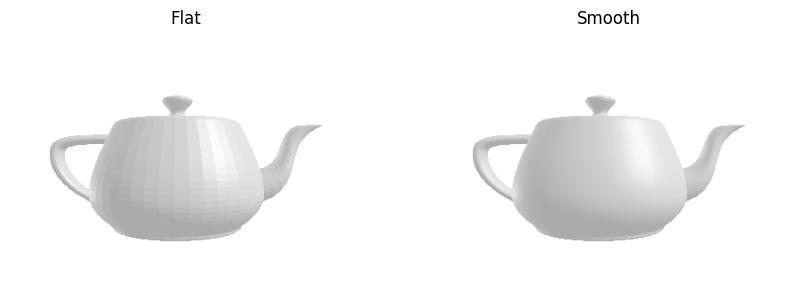

In [5]:
#create scene
sc = tm.Scene(obj)
#get image info
flat = sc.save_image((400,300), smooth=False)
smooth = sc.save_image((400,300), smooth=True)
#readable format for matplot
img_flat = mpimg.imread(BytesIO(flat), format="png")
img_smooth = mpimg.imread(BytesIO(smooth), format="png")

#show images
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(10)

ax1.imshow(img_flat)
ax1.set_title('Flat')
ax1.axis('off')

ax2.imshow(img_smooth)
ax2.set_title('Smooth')
ax2.axis('off')

plt.savefig("../media/shading_comp.png")
plt.show()

In [ ]:
for i, normal in enumerate(face_normals):
    #check is normalized
    magnitude = np.linalg.norm(normal)
    if magnitude - 1 > 0.01:
        print(f"face {i} normal vector is not normalized (mag = {magnitude})")

#check is pointing correctly
ray_s = obj.triangles_center[i] - (obj.face_normals * 0.1)

i_mesh, i_ray = obj.ray.intersects_id(ray_s, obj.face_normals, multiple_hits=True)

is_inside = np.zeros(len(obj.faces), dtype=bool)

if len(i_mesh) > 0:
    hit_normals = obj.face_normals[i_mesh]
    dot_products = np.einsum('ij,ij->i', face_normals[i_mesh], hit_normals)
    is_inside[i_ray] = (dot_products < 0)

flipped_indices = np.where(is_inside)[0]
if len(flipped_indices):
    print(f"Indices of flipped face normals: {flipped_indices}")
    #correct inverted normals
    for i in flipped_indices:
        face_normals[i] = -face_normals[i]
    print("All normals have been corrected")
else:
    print("All normals are correct")


True
True
Indices of flipped face normals: []
